In [1]:
import pandas as pd
import numpy as np
import plotly.express as px
from sklearn.model_selection import train_test_split
from category_encoders import OneHotEncoder
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
import math
from xgboost import XGBRegressor
from sklearn.pipeline import Pipeline
from skopt import BayesSearchCV
from skopt.space import Real, Categorical, Integer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.feature_selection import RFE

## **Exploratory Data Analysis (EDA)**


Exploratory Data Analysis, commonly known as EDA, is a technique to analyze the data with visuals. It involves using statistics and visual techniques to identify particular trends in data. 
 
It is used to understand data patterns, spot anomalies, check assumptions, etc. The main purpose of EDA is to help look into the data before making any hypothesis about it.

EDA is an important step in the process of building a machine learning model. It enables us to understand how the variables are distributed, related and which features will have good predictive power.

First, let's read in the dataset, which is stored in the `insurance.csv` file in the `input` folder:

In [2]:
data=pd.read_csv('data/insurance.csv')

Now we can eyeball the dataset:

In [3]:
data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


### **Data Dictionary**

The column defintions are below:

* `age`: Age of primary beneficiary.
* `sex`: Gender of primary benficiary.
* `bmi`: Body mass index of primary benficiary: $\frac{weight_{kg}}{(height_{metres})^2}$
* `children`: Number of children that the primary beneficiary has.
* `smoker`: Whether the primary beneficiary smokes.
* `region`: The primary beneficiary's residential area in the US.
* `charges`: Individual medical costs billed by health insurance.

Let's return the datatypes of the columns:

In [4]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


So we have three numeric features (`age`, `bmi` and `children`) and three categorical features (`sex`, `smoker` and `region`).

**NOTE:** there are no null values in any of the columns, which means we won't need to impute values in the **Data preprocessing** step.

This, however, is usually a step that you'll need to consider when building a machine learning model.
The target (i.e. the variable that we want to predict) is the `charges` column, so let's split the dataset into features (`X`) and the target (`y`):


In [5]:
target='charges'
X=data.drop(target,axis=1)
y=data[target]

Check dataframe shapes:

In [6]:
X.shape, y.shape

((1338, 6), (1338,))

### **Distributions**

Let's now look at the distribution of each feature by plotting a histogram for each:

In [7]:
def plot_histograms(X,height=1200):
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    fig =make_subplots(rows=X.shape[1],cols=1)
    for i, col in enumerate(X.columns):
        fig.add_trace(
            go.Histogram(
                x=X[col],
                name=col,
            ),
            row=i+1,
            col=1
        )
        fig.update_xaxes(
        title_text=col,
        row=i+1,
        col=1
        )
        fig.update_yaxes(
        title_text='count',
        row=i+1,
        col=1
        )
    fig.update_layout(height=height)
    fig.show()

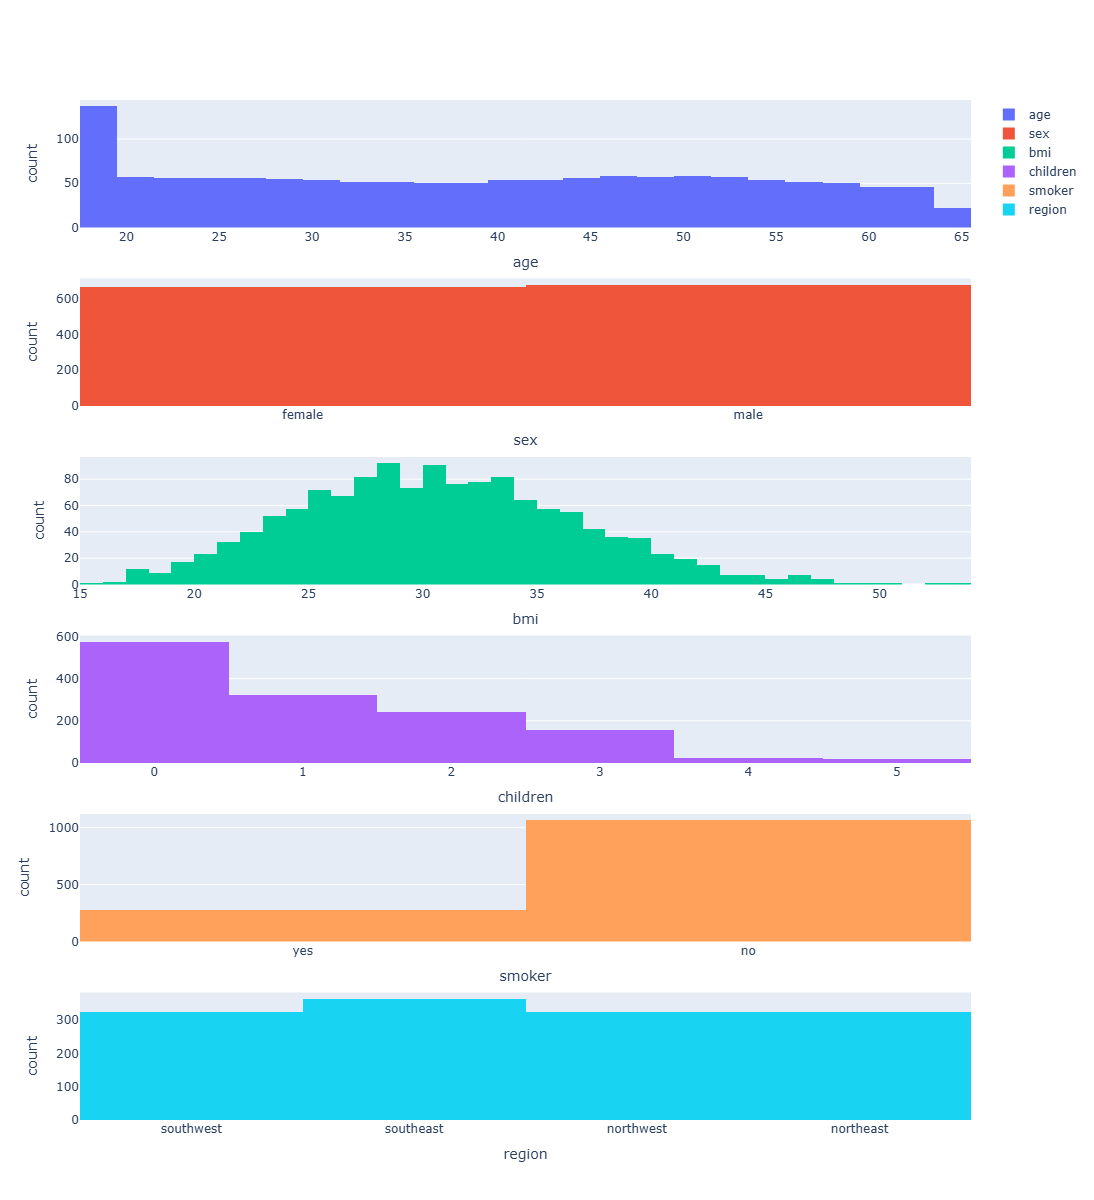

In [8]:
plot_histograms(X)

Points to note regarding the distribution of each feature:

* `age` - Approximately uniformly distributed.
* `sex` - Approximately equal volume in each category.
* `bmi` - Approximately normally distributed.
* `children` - Right skewed (i.e. higher volume in lower range).
* `smoker` - Significantly more volume in the `no` category vs the `yes` category.
* `region` - Approximately equal volume in each category.

We can also observe the distribution of the target:

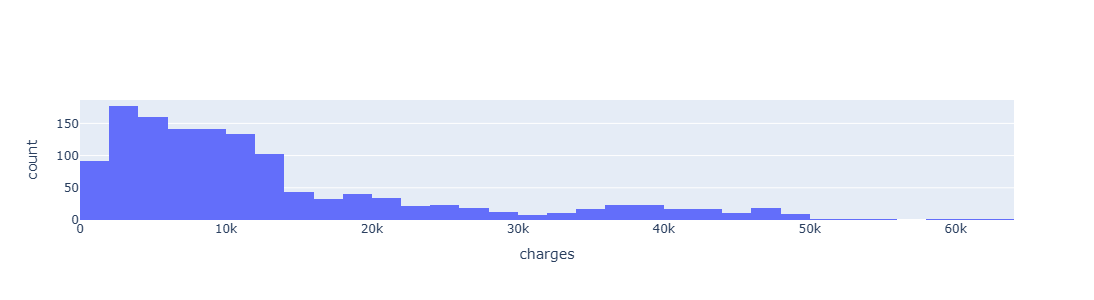

In [9]:
plot_histograms(pd.DataFrame(y), height=300)

The distribution is right skewed (i.e. higher volume in the lower range).

### **Univariate analysis (with respect to the target)**

Let's now apply univariate analysis with respect to the target. This means that we take each feature and see how it relates to the target.

The way in which we do this depends on whether the feature is numeric or categorical. For numeric features, we'll use a scatterplot; for categorical features, we'll use boxplots.

#### Numeric features

In [10]:
def plot_univariate_numeric(X,y):
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    fig = make_subplots(rows=X.shape[1], cols=1)
    for i, col in enumerate(X.columns):
        fig.add_trace(
            go.Scatter(
                x=X[col],
                y=y,
                name=col,
                mode='markers'
            ),
            row=i+1,
            col=1
        )

        fig.update_xaxes(
            title_text=col,
            row=i+1,
            col=1
        )

        fig.update_yaxes(
            title_text='charges',
            row=i+1,
            col=1
        )

    fig.update_layout(
        height=1200
        )

    fig.show()

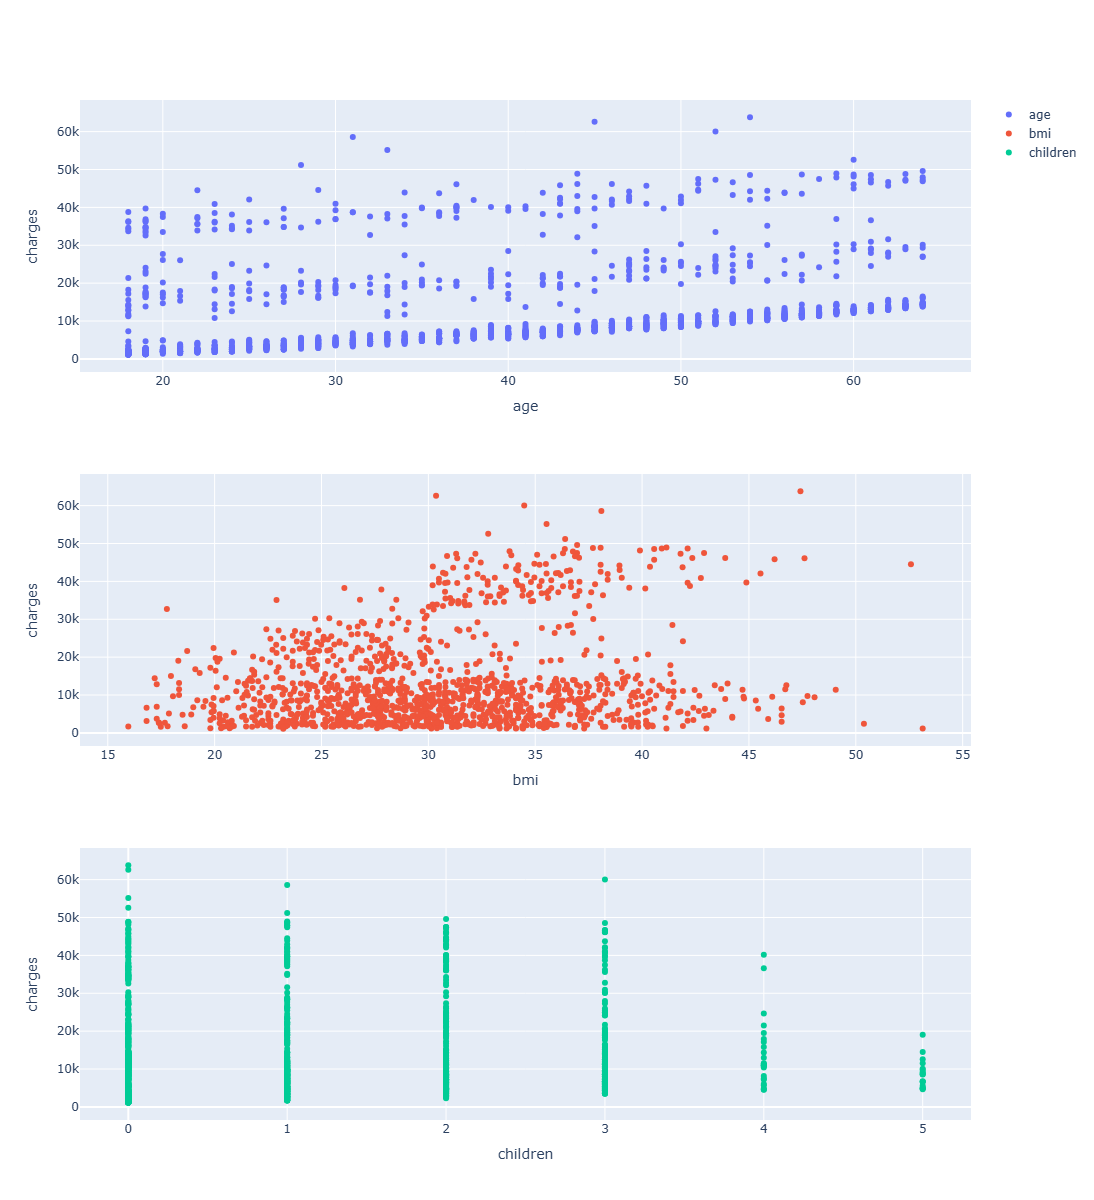

In [11]:
plot_univariate_numeric(
    X.select_dtypes(include=np.number),
    y
)

Points to note regarding each feature:

* `age` - As `age` increases, `charges` also tends to increase (although there is a large variance in `charges` for a given `age`).
* `bmi` - There is no clear relationship, although there seems to be a group of individuals with `bmi` > 30 that have `charges` > 30k. This group may become more apparent when we carry out our bivariate analysis later.
* `children` - No clear relationship (although `charges` seems to decrease as `children` increases). **Since there are only 6 unique values for this feature, let's try treating it as a categorical feature for the purposes of univariate analysis.**

#### Categorical features

In [12]:
def plot_univariate_categorical(X,y):
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    fig = make_subplots(rows=X.shape[1], cols=1)
    for i, col in enumerate(X.columns):
        fig.add_trace(
            go.Scatter(
                x=X[col],
                y=y,
                name=col,
                mode='markers'
            ),
            row=i+1,
            col=1
        )

        fig.update_xaxes(
            title_text=col,
            row=i+1,
            col=1
        )
    fig.update_layout(
            height=1200
    )
    fig.show()
        

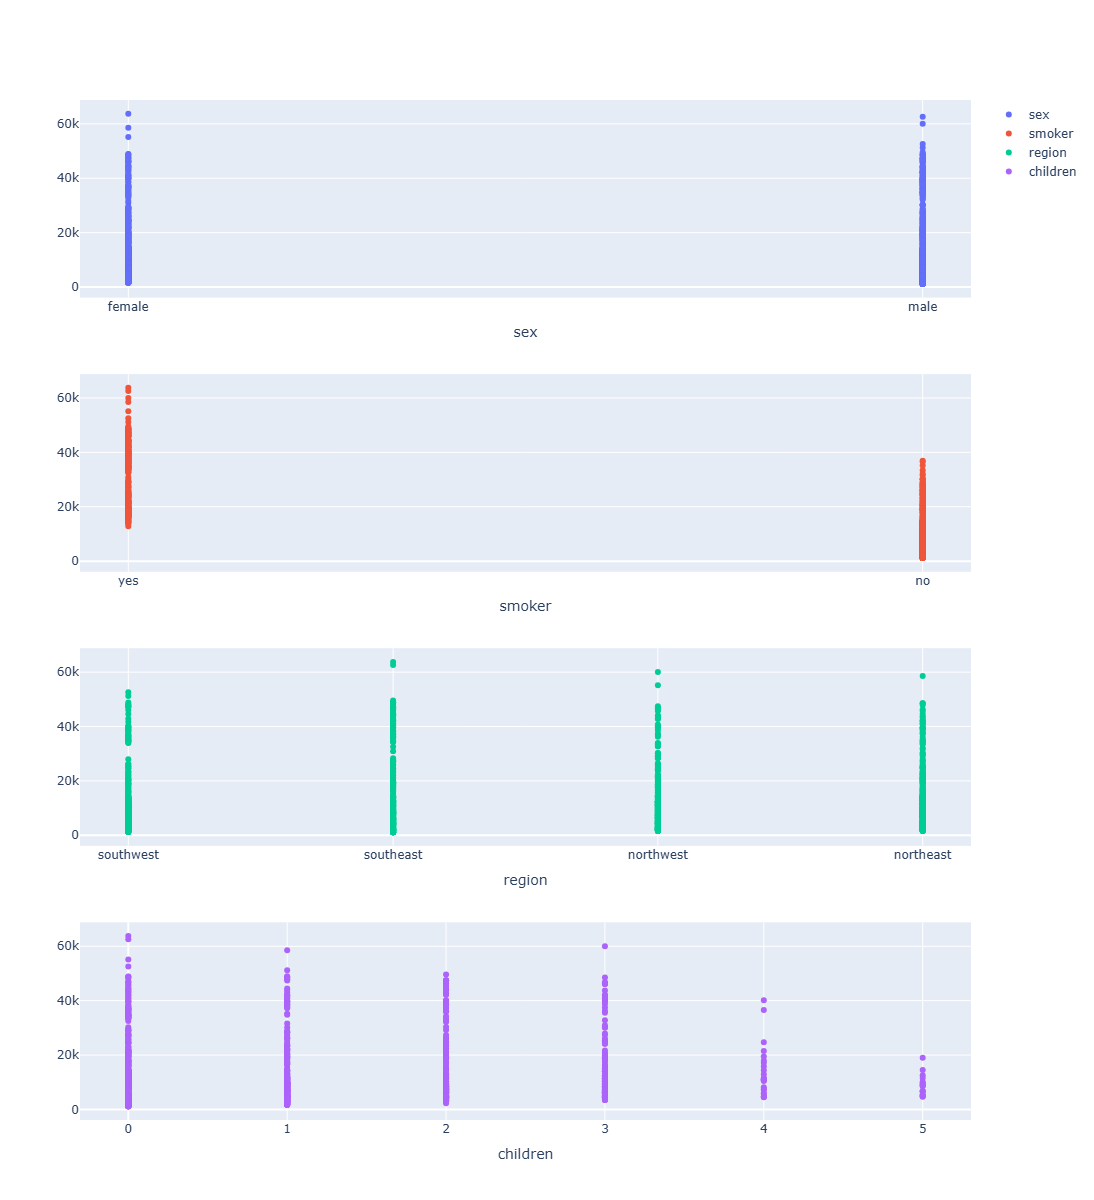

In [13]:
plot_univariate_categorical(
    X[['sex','smoker','region','children']],
    y
)

Points to note regarding each feature:

* `sex` - No significant differences in `charges` between the categories.
* `smoker` - `charges` for `smoker` == 'yes' are generally much higher than when `smoker` == 'no'.
* `region` - No significant differences in `charges` between the categories.
* `children` - No significant differences in `charges` between the categories (`children` >= 4 are skewed towards lower `charges`, but this is likely due to the low volumes in those categories - see the **Distributions** section).

### **Bivariate analysis (with respect to the target)**

Let's now apply bivariate analysis with respect to the target. This means that we take pairs of features and see how they relate to the target.

The way in which we do this depends on whether the feature pairs are all numeric, all categorical or a mixture of categoric and numeric. For all numeric pairs, we'll use a heatmap; for all categorical pairs, we'll use boxplots; for categorical-numeric pairs, we'll use a scatterplot. 

#### **Numeric pairs**

##### **Correlation Heatmap**
 
A correlation heatmap is a heatmap that depicts a two-dimensional correlation matrix between two discrete dimensions, with colored pixels representing data on a color scale. The values of the first dimension are displayed as rows in the table, while the values of the second dimension appear as columns. The cell's hue is proportional to the number of measurements corresponding to the dimensional value.
 
This makes correlation heatmaps great for data analysis since they show differences and variances in the same data while making patterns clearly accessible. A correlation heatmap, like a standard heatmap, is aided by a color bar to make data more legible and understandable.

In [14]:
def plot_heatmap(X,y,bins=10):
    import pandas as pd
    import plotly.express as px
    from itertools import combinations, product
    data=pd.concat([X,y], axis=1)
    for num_col in X.select_dtypes(include=np.number):
        
        if X[num_col].nunique() < bins:
            continue
        else:
            data[num_col] = pd.cut(data[num_col], bins= bins)
    col_pairs = list ( combinations(X.columns,2))
    for col1,col2 in col_pairs:
        col_pair_y_mean = data.groupby(
            [col1,col2]
        )[y.name].mean().reset_index()
        col_pair_y_mean = col_pair_y_mean.pivot (
            index = col1, columns=col2, values=y.name
        )
        col_pair_y_mean.sort_index(ascending= False, inplace= True)
        col_pair_y_mean.index = col_pair_y_mean.index.astype(str)
        col_pair_y_mean.columns= col_pair_y_mean.columns.astype(str)
        fig= px.imshow(col_pair_y_mean)
        fig.show()
    

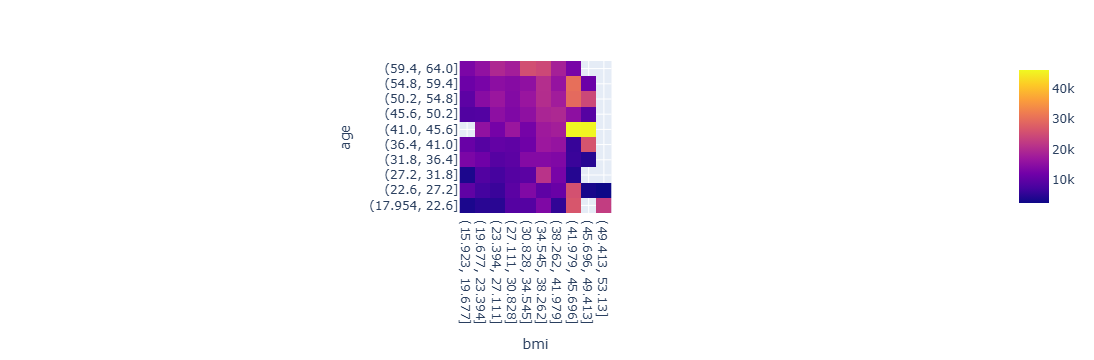

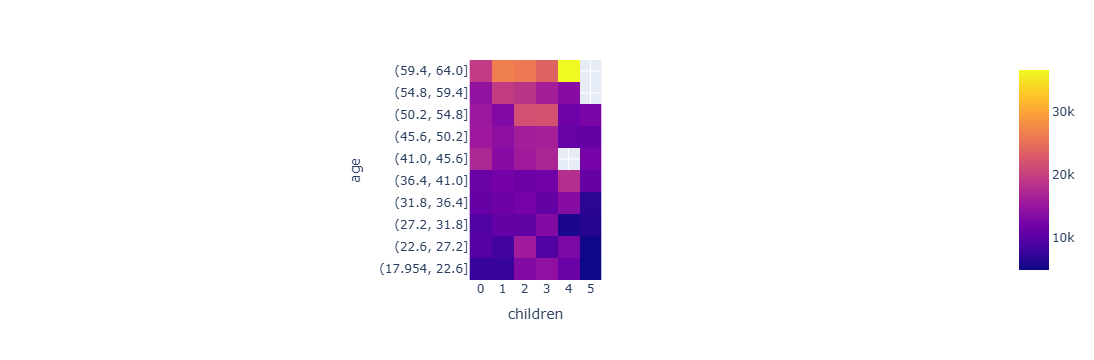

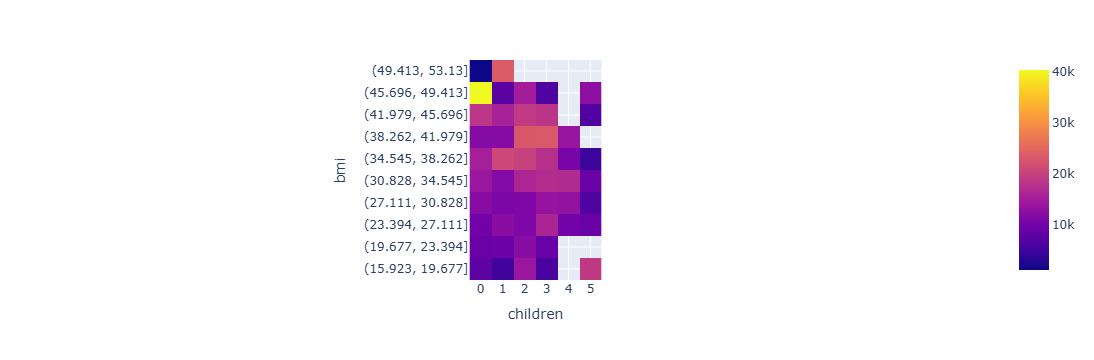

In [15]:
plot_heatmap(
    X[['age','bmi','children']],
       y,
       bins=10
    )

No additional insight can be gained from these plots that we haven't already obtained from the univariate analysis.

#### **Categorical pairs**

**Box Plots**


A box and whisker plot, often known as a box plot, shows a five-number summary of a collection of data. The minimum, first quartile, median, third quartile, and maximum are the five-number summary. A box plot is created by drawing a box from the first to third quartiles which is the Inter Quartile Range (IQR). At the median, a vertical line runs through the box.

In [20]:
def plot_paired_boxplots(X,y):
    from itertools import combinations
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    import pandas as pd
    col_pairs=list(combinations(X.columns,2))
    fig=make_subplots(rows=len(col_pairs),cols=1)
    for i, ( col1,col2) in enumerate(col_pairs):
        paired_cat=col1 + '=' + X[col1] + ',' + col2 + '=' + X[col2]
        fig.add_trace ( 
            go.Box(
                x=paired_cat,
                y=y,
                name=f'{col1} & {col2}'
            ),
            row=i+1,
            col=1
        )
        fig.update_xaxes(
            title_text=f'{col1} & {col2}',
            row=i+1,
            col=1,
            categoryorder='array',
            categoryarray=sorted(paired_cat.unique())
        )
        fig.update_yaxes(
            title_text='charges',
            row=i+1,
            col=1
        )
    fig.update_layout(
            height=1800
    )
    fig.show()
    

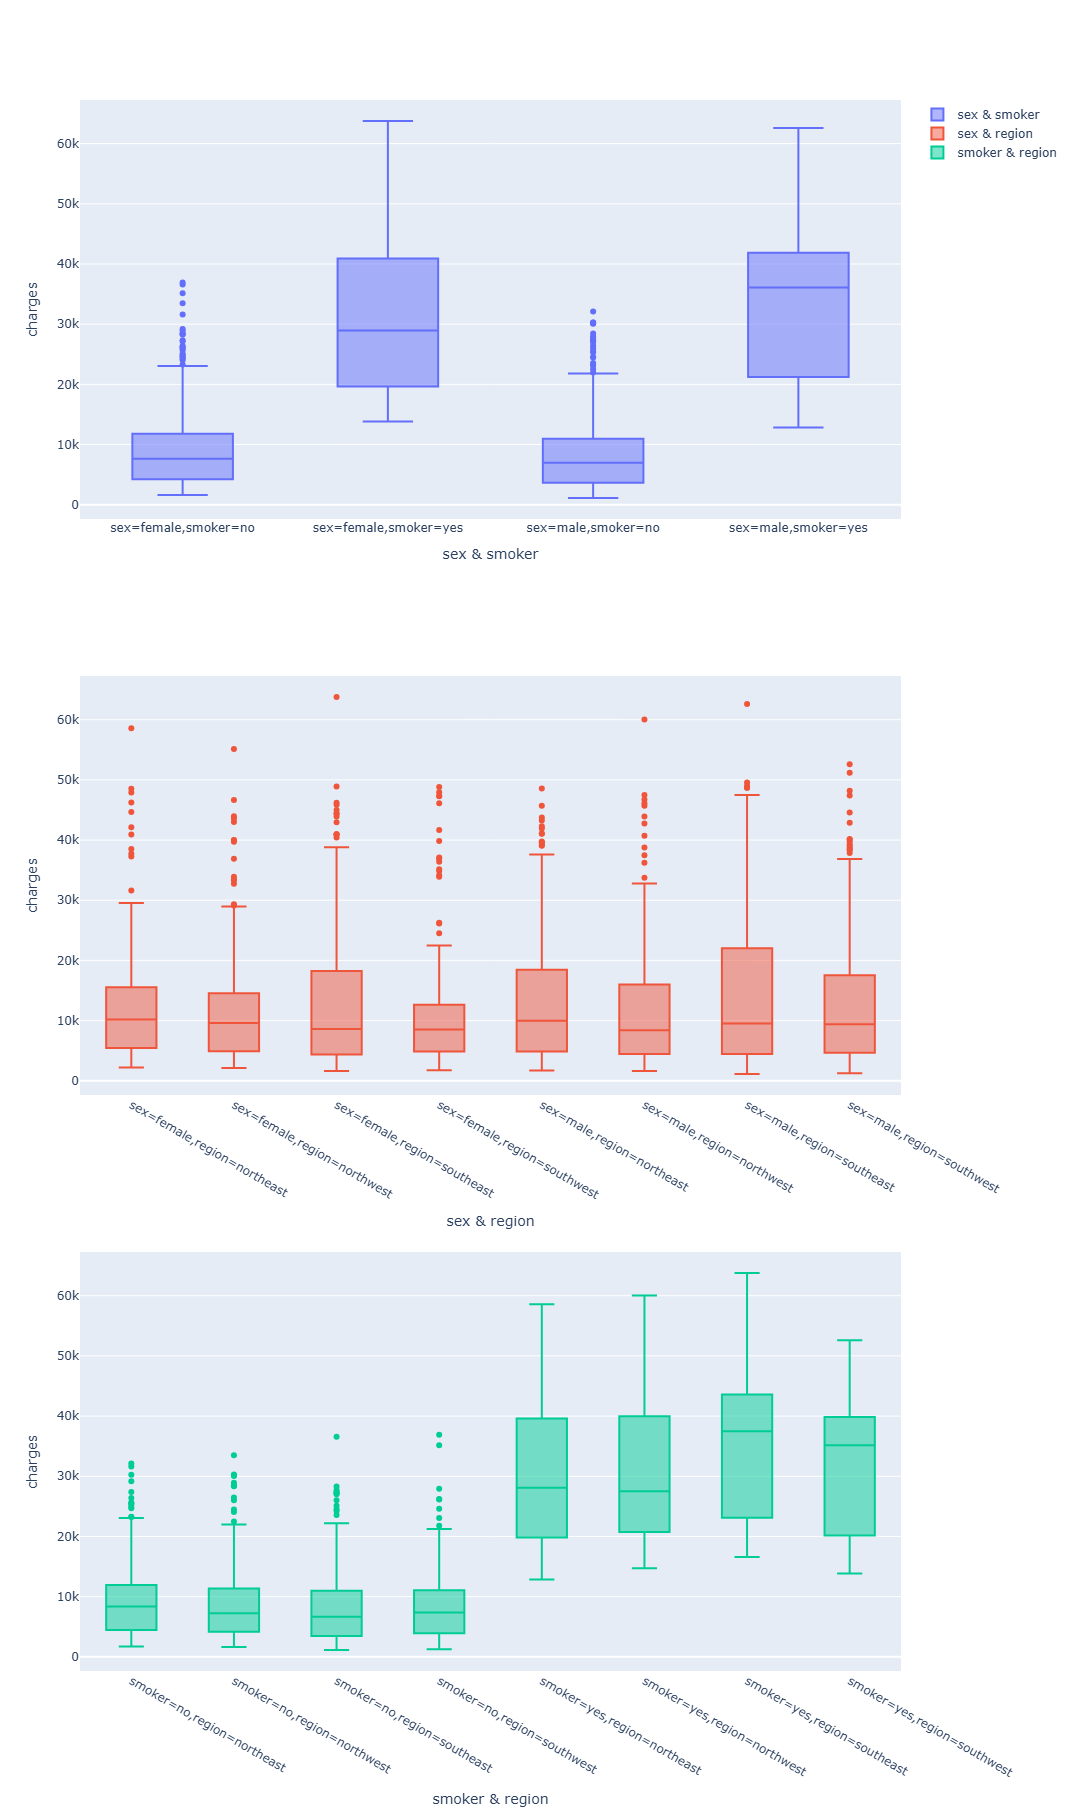

In [21]:
plot_paired_boxplots(
    X[['sex','smoker','region']],
    y
)

Points to note regarding these feature pairs:

* `sex`-`smoker` - The median `charges` is higher for males who smoke compared to females who smoke (36k vs 29k)
* `smoker`-`region` - The median `charges` is higher for smokers in the southwest and southeast vs the northeast and northwest (35k and 37k vs 28k and 27k)

#### **Numeric-categorical pairs**

In [28]:
def plot_paired_scatterplots(X,y):
    import pandas as pd
    import numpy as np
    from itertools import product
    from plotly.subplots import make_subplots
    import plotly.graph_objects as go
    data=pd.concat([X,y],axis=1)
    num_cols=X.select_dtypes(np.number).columns
    cat_cols=X.select_dtypes(object).columns
    col_pairs=list(product(num_cols,cat_cols))
    fig=make_subplots(rows=len(col_pairs), cols=1)
    j=1
    for i, (col1,col2) in enumerate(col_pairs):
        for col2_val in X[col2].unique():
            mask=X[col2]==col2_val
            X_=X[mask]
            y_=y[mask]
            fig.add_trace(
                go.Scatter(
                    x=X_[col1],
                    y=y_,
                    name=col2_val,
                    mode='markers',
                    legendgroup=j
                ),
                row=i+1,
                col=1
            )
        fig.update_xaxes(title_text=col1, row=i+1, col=1)
        fig.update_yaxes(title_text=y.name, row=i+1, col=1)
        j += 1
    fig.update_layout(
        height=4800,
        legend_tracegroupgap=485,
    )
    fig.show()
        

/tmp/ipykernel_916/3210666677.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(object).columns


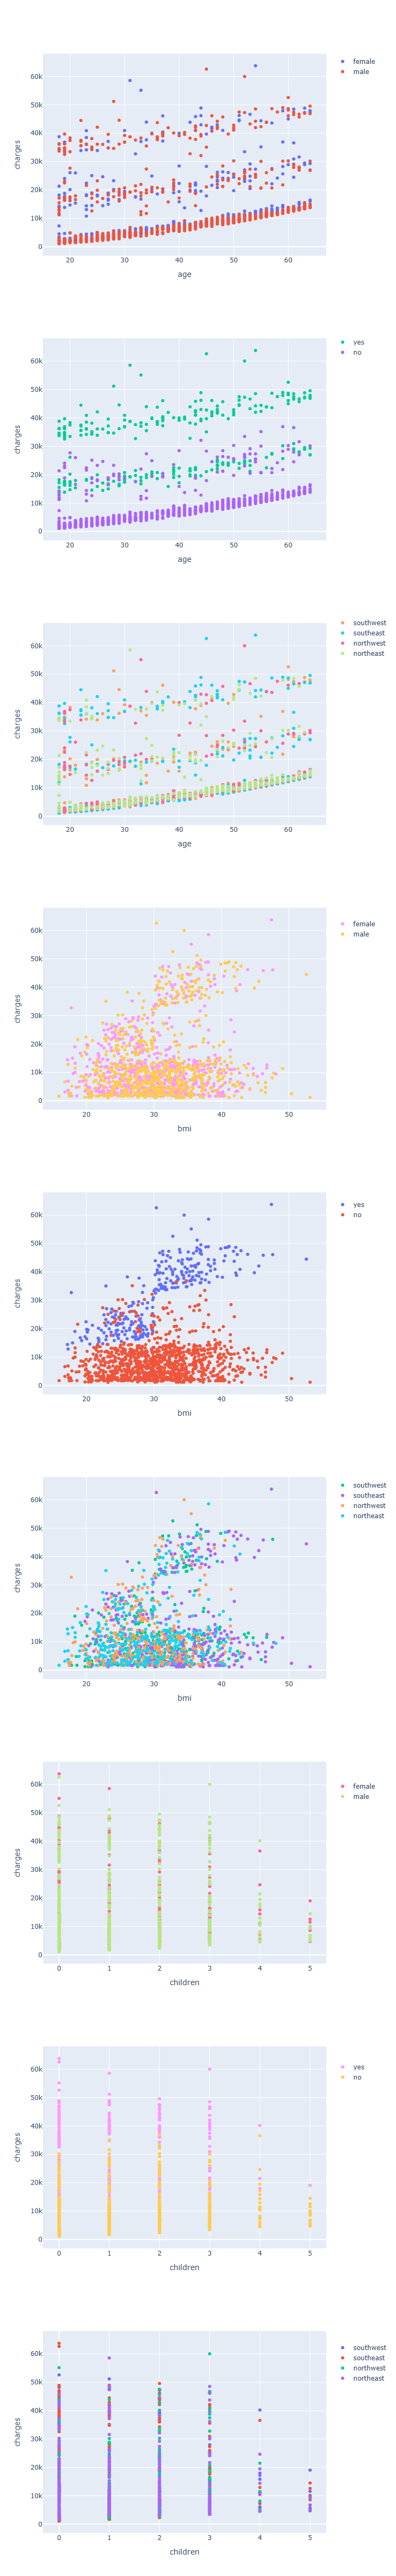

In [29]:
plot_paired_scatterplots(X,y)

There are two pieces of insight from these graphs:

* `age`-`smoker` - There is a group in the bottom left hand quadrant of the chart (where `age` < 50 and `smoker` = 'no') where all beneficiaries have health care costs below 10k (which is relatively small compared to the rest of the population).
* `bmi`-`smoker` - There is a group in the top right hand quadrant of the chart (where `bmi` > 30 and `smoker` = 'yes') where all beneficiaries have health care costs above 30k (which is relatively large compared to the rest of the population).

### **Collinearity (between features)**

Now let's look at collinearity (i.e correlation) between features.

The way in which we do this depends on whether the feature pairs are all numeric, all categorical or a mixture of categoric and numeric. For all numeric pairs, we'll use the **Pearson's correlation**; for all categorical pairs, we'll use a **$\chi^2$ test**; for categorical-numeric pairs, we'll use an **Analysis of Variance (ANOVA) test**. 

#### **Numeric features**

First, let's use a pairplot to see how each pair of numeric features relate to one another:

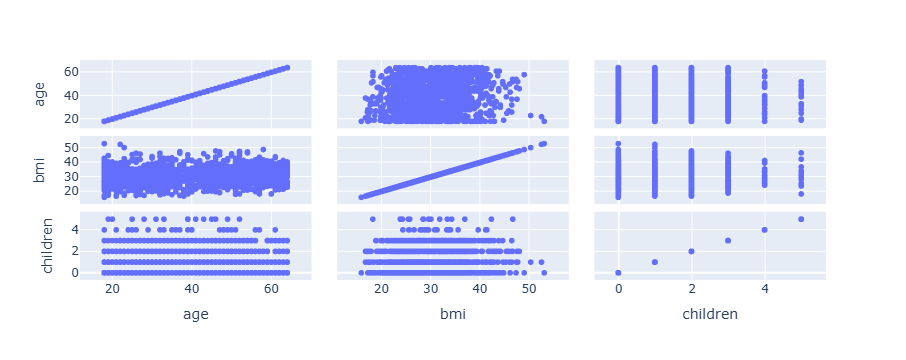

In [32]:
px.scatter_matrix(
    X.select_dtypes(include=np.number)
)

There doesn't look like there's much correlation between any of the numeric features. To be sure, let's calculate and plot the **Pearson's correlation matrix**:

**Correlation**

Correlation coefficient is used to measure the strength of relationship between two variables. It indicates that as the value of one variable changes the other variable changes in a specific direction with some magnitude. There are various ways to find correlation between two variables, one of which is Pearson correlation coefficient.
It measures the linear relationship between two continuous variables.
 
Let's say $x$ and $y$ are two continuous variables, the Pearson correlation coefficient between them can be found by the following formula.
 
 
$$r = \frac{ \sum_{i=1}^{n}(x_i-\bar{x})(y_i-\bar{y}) }{%
        \sqrt{\sum_{i=1}^{n}(x_i-\bar{x})^2}\sqrt{\sum_{i=1}^{n}(y_i-\bar{y})^2}}$$
 
where $x_i$ and $y_i$ represents the $i^{th}$ value of the variables.
The value of $r$ ranges between $-1$ and $+1$.
 
Their strength of relationship is measured by the absolute value of coefficient, whereas the sign of the coefficient indicates the direction of the relationship.
 



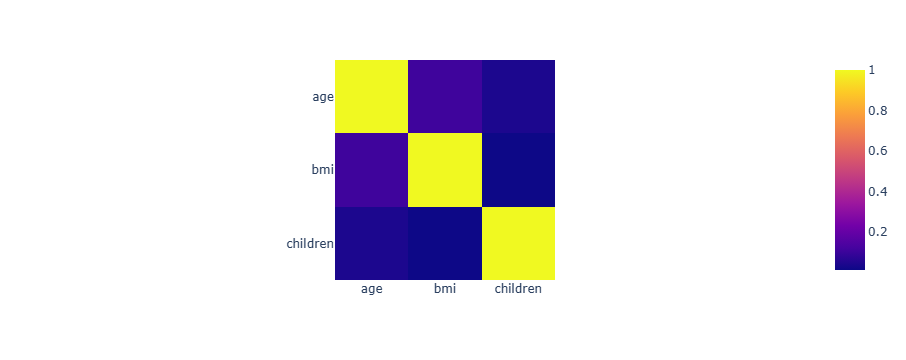

In [33]:
px.imshow(X.select_dtypes(include=np.number).corr())

This suggests there is very little correlation between the numeric features.

#### **Categorical features**

 **Chi Squared Test**

A sample's distribution of a categorical variable must frequently be compared to the distribution of a categorical variable in another sample.

The chi squared test of independence, often known as the chi squared test of association, is used to detect whether or not categorical variables are related. 

The data must meet the following requirements for this test:

* Categorical variables
* Sample size is relatively large
* Independent observations

The chi squared test is performed in the following steps:
* Find a "expected" number (E) for each observed number (0) in the table.

$$χ^2  = \frac{∑(O_i – E_i)^2}{E_i}$$

* A chi-square test will provide us with a p-value. The p-value indicates whether or not our test results are significant.

However, in order to do a chi-square test and calculate the p-value, we need two pieces of information:

* Degrees of freedom. That is simply the number of categories minus one.

* Significance Level. The standard alpha level is 0.05 (5%), but alternative values such as 0.01 or 0.10 are possible.

* The following are the different values of p that indicate different hypothesis interpretations:

* P = 0.05; Hypothesis is rejected
* P > 0.05; Acceptance of Hypothesis

Watch the videos, [Degrees of Freedom Part 1](https://www.projectpro.io/project/hackerday-project/project-title/piecewise%20spline%20regression%20project#sub-hackerday-video-18) and [Degrees of Freedom Part 2](https://www.projectpro.io/project/hackerday-project/project-title/piecewise%20spline%20regression%20project#sub-hackerday-video-19) to understand the basics of Degrees of Freedom and their interpretation.





For categorical features, we'll use a Chi Squared ($\chi^2$) test to observe whether each categorical feature pair is correlated.

First, we calculate the $\chi^2$ values, p-values and degrees of freedom:

In [37]:
def chi2(X,correction=True):
    from itertools import combinations, product
    import pandas as pd
    import numpy as np
    import scipy.stats as stats
    col_pairs=list(combinations(X.columns,2))
    results_list=[]
    for col1,col2 in col_pairs:
        contigency=pd.crosstab(
            X[col1],
            X[col2]
        )
        chi2,p_val,dof,exp_freq=stats.chi2_contingency(
            contigency.values, correction=correction
        )
        results_list.append([col1,col2,chi2,p_val,dof])
    results=pd.DataFrame(
        results_list,
        columns=[
            'column1','column2','chi_squared','p_value','dof' ]
    )
    return results

In [38]:
X_chi2=chi2(X.select_dtypes(object))

/tmp/ipykernel_916/1413270079.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  X_chi2=chi2(X.select_dtypes(object))


In [39]:
X_chi2

,column1,column2,chi_squared,p_value,dof
0,sex,smoker,7.392911,0.006548,1
1,sex,region,0.435137,0.932892,3
2,smoker,region,7.343478,0.061720,3


Since there are only three different categorical feature pairs, we won't plot the results.

We can use the p-value (which is derived from the $\chi^2$ result and the degrees of freedom) to test how likely the observed distribution (for each feature pair) happened due to chance. For example, a p-value of 0.5 means that there is a 50% probability of observing the distribution by chance. 

A threshold of < 0.05 is widely accepted for rejecting the null-hypothesis (that the features are independent) since this means that there is only a 5% probability of observing the distribution by chance.

The only feature pair with a p-value less than this threshold is `sex` and `smoker`, which means it's likely that these features are correlated:

In [40]:
X_chi2[X_chi2['p_value'] < 0.05]

,column1,column2,chi_squared,p_value,dof
0,sex,smoker,7.392911,0.006548,1


#### **Numeric-categorical feature pairs**

**ANOVA**



For numeric-categorical feature pairs, we'll use an ANOVA test. ANOVA stands for Analysis of Variance - it helps us to understand if there are statistically significant differences between the means of independent groups.



ANOVA is an abbreviation for Analysis of Variances, which evaluates the differences between group means. It's a statistical hypothesis test that looks to see if the means of at least two populations differ. To run ANOVA, we require at least one continuous variable and one categorical variable that separates your data into comparison groups. The term "analysis of variances" refers to how the test uses variances to determine whether the means are different.


ANOVA compares the variance of group means to the variance of the groups. This procedure establishes if the groups are part of a bigger population or if they are separate populations with different means.

Despite the fact that it analyses variations, it tests means. One way ANOVA is the most basic sort of ANOVA. This method is a generalisation of t tests that can be used to compare more than two groups.

The null hypothesis is that all groups have same mean and the alternate hypothesis is that atleast one group has different mean.

Watch full explanation for [Introduction to ANOVA](https://www.projectpro.io/project/hackerday-project/project-title/polynomial%20regression%20model%20in%20python%20from%20scratch#sub-hackerday-video-18) here.

First, we calculate the $F$ values (the ratio of the between- and within-group mean squares) and p-values:

In [45]:
def anova(X):
    from itertools import combinations, product
    import pandas as pd
    import numpy as np
    import scipy.stats as stats
    num_cols=X.select_dtypes(np.number).columns
    cat_cols=X.select_dtypes(object).columns
    col_pairs=list(product(num_cols,cat_cols))
    results_list=[]
    for num_col, cat_col in col_pairs:
        X_filtered_list=[]
        cat_calues=X[cat_col].unique()
        for cat_value in cat_calues:
            X_filtered_list.append(X[X[cat_col] == cat_value][num_col].values)
        f_stat,p_val=stats.f_oneway(*X_filtered_list)
        results_list.append([num_col,cat_col,f_stat,p_val])
    results=pd.DataFrame(
        results_list,
        columns=[
            'num_column','cat_column','f_stat','p_value'
        ]
    )
    return results

In [46]:
X_anova=anova(X)

/tmp/ipykernel_916/1562366742.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(object).columns


In [47]:
X_anova

,num_column,cat_column,f_stat,p_value
0,age,sex,0.581369,4.459107e-01
1,age,smoker,0.836777,3.604853e-01
2,age,region,0.079782,9.709891e-01
3,bmi,sex,2.878970,8.997637e-02
4,bmi,smoker,0.018792,8.909850e-01
5,bmi,region,39.495057,1.881839e-24
6,children,sex,0.393659,5.304898e-01
7,children,smoker,0.078664,7.791596e-01
8,children,region,0.717493,5.415543e-01


Similar to the $\chi^2$ test above, we can use the p-value to test how likely the observed distribution (for each feature pair) happened due to chance. We will again apply the threshold of < 0.05 isfor rejecting the null-hypothesis (that the features are independent).

The only feature pair with a p-value less than this threshold is `bmi` and `region`, which means it's likely that these features are correlated:

In [48]:
X_anova[X_anova['p_value'] < 0.05]

,num_column,cat_column,f_stat,p_value
5,bmi,region,39.495057,1.881839e-24


### **Correlation (with respect to the target)**

Now we will calculate the correlation between the features and the target. This will be useful when it comes to building our baseline linear model.

We can apply the same techniques that we used when calculating collinearity between features.

#### **Numeric features (with respect to the target)**

Here, we'll calculate the Pearson's Correlation between each numeric feature and the target:

In [51]:
def plot_pearson_wrt_target(X,y):
    
    import pandas as pd
    import numpy as np
    import plotly.express as px
    data=pd.concat([X,y],axis=1)
    data_corr=data.select_dtypes(np.number).corr()
    data_corr.index.name='features'
    data_corr=data_corr.reset_index()
    data_corr=data_corr[data_corr['features'] != y.name]
    fig=px.bar(
        data_frame=data_corr.reset_index(),
        x='features',
        y='charges'
    )
    fig.update_yaxes(title='correlation')
    fig.show()

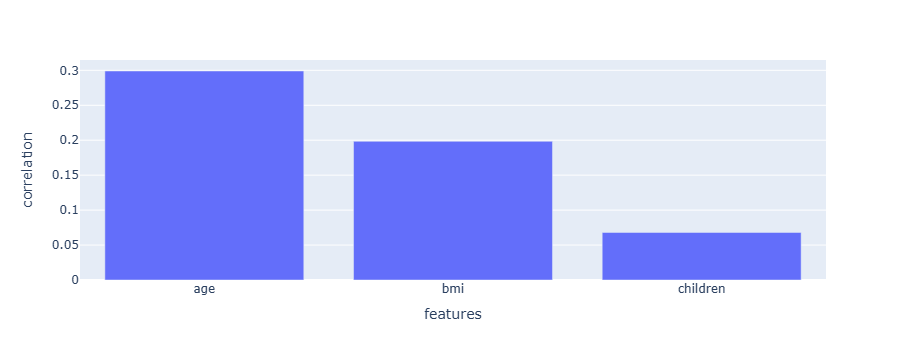

In [52]:
plot_pearson_wrt_target(X, y)

The `children` feature has a very low correlation with respect to the target.

#### **Categorical features (with respect to the target)**

Here, we'll apply the ANOVA test. Note that since we're only interested in comparing each categorical feature to the target, we filter out the results of all other numeric features:

In [53]:
data_anova=anova(data)
anova_wrt_target=data_anova[data_anova['num_column']=='charges']

/tmp/ipykernel_916/1562366742.py:7: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols=X.select_dtypes(object).columns


In [54]:
anova_wrt_target

,num_column,cat_column,f_stat,p_value
9,charges,sex,4.399702,3.613272e-02
10,charges,smoker,2177.614868,8.271436e-283
11,charges,region,2.969627,3.089336e-02


All p-values are < 0.05, which means that the differences observed in the `charges` column when comparing the categories within a categorical variable are statistically significant. **Note however that this doesn't measure the magnitude of the differences observed.**